# 03. Weekly strategy labels

Generates the project's **base table**: for every `(ticker, Monday, strategy_type, yield_target)` combination in the clean Mon->Fri universe, pick the best-matching option contract and record entry + outcome + P&L.

Output: `data/strategy_labels.parquet`. Every downstream notebook (04, 05-08, 09, 10, 11, 12) reads this instead of re-processing raw option chains.

**Settings (all in cell 2, tweak there and re-run):**

- `UNIVERSE` = `HIGH_QUALITY_TICKERS` (35 tickers)
- `TYPES` = `["CC", "CSP"]` (covered call, cash-secured put; OTM-only)
- `YIELD_TARGETS` = `[0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]` (10 points, 0.5%-5% weekly)
- `EXPECTED_DTE = 4` (strict Mon-close -> Fri-close, drops holiday weeks)
- `MIN_BID = 0.05`, `MIN_OI = 10` (contract quality gates)
- `YIELD_MATCH_TOLERANCE = 0.25` (drop if best available yield is >25% off target)

**Selection rule per `(ticker, monday, type, yield_target)`:**

1. Require Monday AND Friday to be NYSE trading days (AAPL's calendar as proxy).
2. Require an options expiration exactly on that Friday (DTE = 4).
3. Filter chain to OTM contracts of the correct type (`CC` -> calls with `strike > spot`; `CSP` -> puts with `strike < spot`).
4. Apply quality gates: `bid >= MIN_BID`, `open_interest >= MIN_OI`.
5. Compute yield per contract: `CC -> mark/spot`, `CSP -> mark/strike`.
6. Pick the contract whose `yield_actual` is closest to `yield_target`.
7. Drop if `|yield_actual - yield_target| / yield_target > YIELD_MATCH_TOLERANCE`.

Every other column (`friday_close`, `assigned`, `pnl_*`, `p_mkt_success`, etc.) follows deterministically.


In [1]:
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from config import HIGH_QUALITY_TICKERS


UNIVERSE = HIGH_QUALITY_TICKERS
TYPES = ["CC", "CSP"]
YIELD_TARGETS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030, 0.035, 0.040, 0.045, 0.050]
EXPECTED_DTE = 4
MIN_BID = 0.05
MIN_OI = 10
YIELD_MATCH_TOLERANCE = 0.25

WINDOW_START = pd.Timestamp("2020-01-01")
WINDOW_END = pd.Timestamp("2026-04-02")

OUT_PARQUET = Path("output/03_weekly_strategy_labels/strategy_labels.parquet")
OUT_CSV = Path("output/03_weekly_strategy_labels/strategy_labels.csv")

DATE_RE = re.compile(r"_(\d{4}-\d{2}-\d{2})\.csv$")
OPTIONS_COLS = [
    "contractID",
    "expiration",
    "strike",
    "type",
    "bid",
    "ask",
    "mark",
    "volume",
    "open_interest",
    "delta",
    "implied_volatility",
]

## Trading calendar + daily close cache

Use AAPL's dates as the NYSE calendar proxy. Build a per-ticker `date -> close` dict up front so we can look up Friday's underlying close in O(1).


In [2]:
def load_trading_days():
    df = pd.read_csv("data/daily_alpha/AAPL.csv", usecols=["date"])
    return set(pd.to_datetime(df["date"]).dt.date)


def load_daily_close(ticker):
    p = Path("data/daily_alpha") / f"{ticker}.csv"
    if not p.exists():
        return {}
    df = pd.read_csv(p, usecols=["date", "close"])
    df["date"] = pd.to_datetime(df["date"]).dt.date
    return dict(zip(df["date"], df["close"].astype(float)))

## Build the labels

Single pass: for each ticker, iterate all Monday option-chain files in the window, apply selection rule, emit one row per `(type, yield_target)` that survives the filters. Prints progress per ticker and drop counts at the end.


In [3]:
def build_labels():
    trading_days = load_trading_days()
    drops = {
        "no_monday_file": 0,
        "monday_holiday": 0,
        "friday_holiday": 0,
        "no_friday_close": 0,
        "no_exact_friday_expiry": 0,
        "no_otm_of_type": 0,
        "bid_or_oi_filter": 0,
        "yield_out_of_reach": 0,
    }
    rows = []

    for ticker_i, ticker in enumerate(UNIVERSE):
        tdir = Path("data/options_alpha") / ticker
        if not tdir.is_dir():
            continue
        daily_close = load_daily_close(ticker)

        mondays = []
        for f in tdir.iterdir():
            m = DATE_RE.search(f.name)
            if not m:
                continue
            snap = pd.Timestamp(m.group(1))
            if snap.weekday() != 0 or not (WINDOW_START <= snap <= WINDOW_END):
                continue
            mondays.append((snap, f))
        mondays.sort()

        for snap, snap_file in mondays:
            if snap.date() not in trading_days:
                drops["monday_holiday"] += 1
                continue
            friday = snap + pd.Timedelta(days=EXPECTED_DTE)
            if friday.date() not in trading_days:
                drops["friday_holiday"] += 1
                continue
            if friday.date() not in daily_close:
                drops["no_friday_close"] += 1
                continue

            spot = daily_close.get(snap.date())
            if spot is None:
                drops["no_monday_file"] += 1
                continue

            friday_close = daily_close[friday.date()]

            chain = pd.read_csv(snap_file, usecols=OPTIONS_COLS)
            chain["expiration"] = pd.to_datetime(chain["expiration"])
            for numcol in (
                "bid",
                "ask",
                "mark",
                "delta",
                "implied_volatility",
                "open_interest",
                "strike",
            ):
                chain[numcol] = pd.to_numeric(chain[numcol], errors="coerce")
            chain = chain.dropna(subset=["delta", "mark", "bid", "ask", "strike"])

            friday_chain = chain[chain["expiration"].dt.date == friday.date()]
            if friday_chain.empty:
                drops["no_exact_friday_expiry"] += 1
                continue

            for type_key, opt_type, direction in [
                ("CC", "call", 1),
                ("CSP", "put", -1),
            ]:
                typed = friday_chain[friday_chain["type"] == opt_type]
                typed = (
                    typed[typed["strike"] > spot]
                    if direction == 1
                    else typed[typed["strike"] < spot]
                )
                if typed.empty:
                    drops["no_otm_of_type"] += 1
                    continue

                typed = typed[
                    (typed["bid"] >= MIN_BID) & (typed["open_interest"] >= MIN_OI)
                ]
                if typed.empty:
                    drops["bid_or_oi_filter"] += 1
                    continue

                if type_key == "CC":
                    typed = typed.assign(yield_actual=typed["mark"] / spot)
                else:
                    typed = typed.assign(yield_actual=typed["mark"] / typed["strike"])

                for yt in YIELD_TARGETS:
                    diffs = (typed["yield_actual"] - yt).abs()
                    best_idx = diffs.idxmin()
                    best = typed.loc[best_idx]
                    if abs(best["yield_actual"] - yt) / yt > YIELD_MATCH_TOLERANCE:
                        drops["yield_out_of_reach"] += 1
                        continue

                    strike = float(best["strike"])
                    mark = float(best["mark"])
                    bid = float(best["bid"])
                    ask = float(best["ask"])
                    delta = float(best["delta"])
                    iv = float(best["implied_volatility"])

                    if type_key == "CC":
                        moneyness_actual = strike / spot - 1.0
                        capital = spot * 100.0
                        assigned = friday_close > strike
                        intrinsic = max(0.0, friday_close - strike)
                    else:
                        moneyness_actual = 1.0 - strike / spot
                        capital = strike * 100.0
                        assigned = friday_close < strike
                        intrinsic = max(0.0, strike - friday_close)

                    prem_mark = mark * 100.0
                    prem_bid = bid * 100.0
                    assignment_pnl = -intrinsic * 100.0 if assigned else 0.0
                    net_pnl_mark = prem_mark + assignment_pnl
                    net_pnl_bid = prem_bid + assignment_pnl

                    rows.append(
                        {
                            "ticker": ticker,
                            "monday_date": snap.date(),
                            "friday_date": friday.date(),
                            "dte": EXPECTED_DTE,
                            "type": type_key,
                            "yield_target": yt,
                            "monday_close": spot,
                            "contract_id": best["contractID"],
                            "strike": strike,
                            "moneyness_actual": moneyness_actual,
                            "premium_mark": mark,
                            "bid": bid,
                            "ask": ask,
                            "spread_rel": (ask - bid) / mark if mark > 0 else None,
                            "delta": delta,
                            "iv": iv,
                            "yield_actual": float(best["yield_actual"]),
                            "friday_close": friday_close,
                            "return_pct": (friday_close / spot) - 1.0,
                            "assigned": bool(assigned),
                            "intrinsic_at_expiry": intrinsic,
                            "premium_received_mark": prem_mark,
                            "premium_received_bid": prem_bid,
                            "assignment_pnl": assignment_pnl,
                            "net_pnl_mark": net_pnl_mark,
                            "net_pnl_bid": net_pnl_bid,
                            "capital_per_contract": capital,
                            "pnl_pct_capital": net_pnl_bid / capital,
                            "p_mkt_success": 1.0 - abs(delta),
                        }
                    )

        print(
            f"  [{ticker_i + 1:2d}/{len(UNIVERSE)}] {ticker:6s}  cumulative rows: {len(rows)}"
        )

    df = pd.DataFrame(rows)
    df["monday_date"] = pd.to_datetime(df["monday_date"])
    df["friday_date"] = pd.to_datetime(df["friday_date"])
    return df, drops


t0 = time.time()
print(f"Building labels for {len(UNIVERSE)} tickers...")
labels, drops = build_labels()
elapsed = time.time() - t0

print(f"\nBuilt {len(labels):,} rows in {elapsed:.1f}s")
print("Drop counter:")
for k, v in drops.items():
    print(f"  {k:26s}: {v:>8,}")

Building labels for 35 tickers...
  [ 1/35] AAPL    cumulative rows: 1,322
  [ 2/35] AMAT    cumulative rows: 3,593
  [ 3/35] AMD     cumulative rows: 6,480
  [ 4/35] AMZN    cumulative rows: 8,344
  [ 5/35] APLD    cumulative rows: 9,795
  [ 6/35] AVGO    cumulative rows: 11,848
  [ 7/35] BBAI    cumulative rows: 12,446
  [ 8/35] BULL    cumulative rows: 12,838
  [ 9/35] COIN    cumulative rows: 16,291
  [10/35] DELL    cumulative rows: 17,515
  [11/35] GME     cumulative rows: 21,171
  [12/35] GOOGL   cumulative rows: 22,774
  [13/35] INTC    cumulative rows: 24,829
  [14/35] IONQ    cumulative rows: 26,804
  [15/35] LRCX    cumulative rows: 29,307
  [16/35] META    cumulative rows: 30,639
  [17/35] MSFT    cumulative rows: 31,969
  [18/35] NFLX    cumulative rows: 34,104
  [19/35] NVDA    cumulative rows: 36,858
  [20/35] OKLO    cumulative rows: 38,190
  [21/35] PLTR    cumulative rows: 40,526
  [22/35] QBTS    cumulative rows: 41,497
  [23/35] QCOM    cumulative rows: 43,393
  [24

## Preview

First 8 rows of the base table.


In [4]:
labels.head(8)

,ticker,monday_date,friday_date,dte,type,yield_target,monday_close,contract_id,strike,moneyness_actual,premium_mark,bid,ask,spread_rel,delta,iv,yield_actual,friday_close,return_pct,assigned,intrinsic_at_expiry,premium_received_mark,premium_received_bid,assignment_pnl,net_pnl_mark,net_pnl_bid,capital_per_contract,pnl_pct_capital,p_mkt_success
0,AAPL,2020-01-06,2020-01-10,4,CC,0.005,299.80,AAPL200110C00305000,305.0,0.017345,1.41,1.37,1.45,0.056738,0.27705,0.26853,0.004703,310.33,0.035123,True,5.33,141.0,137.0,-533.0,-392.0,-396.0,29980.0,-0.013209,0.72295
1,AAPL,2020-01-06,2020-01-10,4,CC,0.010,299.80,AAPL200110C00300000,300.0,0.000667,3.27,3.25,3.30,0.015291,0.49855,0.26853,0.010907,310.33,0.035123,True,10.33,327.0,325.0,-1033.0,-706.0,-708.0,29980.0,-0.023616,0.50145
2,AAPL,2020-01-06,2020-01-10,4,CSP,0.005,299.80,AAPL200110P00295000,295.0,0.016011,1.47,1.44,1.50,0.040816,-0.27617,0.26853,0.004983,310.33,0.035123,False,0.00,147.0,144.0,0.0,147.0,144.0,29500.0,0.004881,0.72383
3,AAPL,2020-01-06,2020-01-10,4,CSP,0.010,299.80,AAPL200110P00297500,297.5,0.007672,2.25,2.15,2.36,0.093333,-0.38436,0.26853,0.007563,310.33,0.035123,False,0.00,225.0,215.0,0.0,225.0,215.0,29750.0,0.007227,0.61564
4,AAPL,2020-01-13,2020-01-17,4,CC,0.005,316.96,AAPL200117C00322500,322.5,0.017479,1.84,1.83,1.85,0.010870,0.29639,0.29780,0.005805,318.73,0.005584,False,0.00,184.0,183.0,0.0,184.0,183.0,31696.0,0.005774,0.70361
5,AAPL,2020-01-13,2020-01-17,4,CC,0.010,316.96,AAPL200117C00320000,320.0,0.009591,2.65,2.61,2.68,0.026415,0.38775,0.29780,0.008361,318.73,0.005584,False,0.00,265.0,261.0,0.0,265.0,261.0,31696.0,0.008234,0.61225
6,AAPL,2020-01-13,2020-01-17,4,CC,0.015,316.96,AAPL200117C00317500,317.5,0.001704,3.73,3.70,3.75,0.013405,0.48660,0.29780,0.011768,318.73,0.005584,True,1.23,373.0,370.0,-123.0,250.0,247.0,31696.0,0.007793,0.51340
7,AAPL,2020-01-13,2020-01-17,4,CSP,0.005,316.96,AAPL200117P00310000,310.0,0.021959,1.46,1.43,1.49,0.041096,-0.23855,0.30755,0.004710,318.73,0.005584,False,0.00,146.0,143.0,0.0,146.0,143.0,31000.0,0.004613,0.76145


## Save

- `data/strategy_labels.parquet` (~4209 KB) - **primary artifact**, read by every downstream notebook. Preserves dtypes, fast to load.
- `data/strategy_labels.csv` (~17869 KB) - copy for eyeballing in Excel/VSCode/etc. Same content, larger file, slower to load. Don't use this one programmatically.

Both live in `experiments/data/` which is gitignored (raw data is already excluded). The repo root has a `.gitattributes` with `*.parquet binary` so that if you *do* commit a parquet file later, it won't get corrupted by line-ending conversion on clone.


In [5]:
labels.to_parquet(OUT_PARQUET, index=False)
labels.to_csv(OUT_CSV, index=False)
print(f"Saved {len(labels):,} rows")
print(
    f"  parquet: {OUT_PARQUET} ({OUT_PARQUET.stat().st_size / 1024:,.1f} KB) - primary artifact"
)
print(
    f"  csv:     {OUT_CSV} ({OUT_CSV.stat().st_size / 1024:,.1f} KB) - peek copy, gitignored"
)

Saved 64,339 rows
  parquet: data\strategy_labels.parquet (4,208.5 KB) - primary artifact
  csv:     data\strategy_labels.csv (17,869.0 KB) - peek copy, gitignored


## Quick sanity EDA: success rate vs yield target

For each `(type, yield_target)`, compute:

- `n`: row count
- `pct_OTM_at_exp`: realized success rate (= 100 × fraction not assigned)
- `median_yield_actual`: what yield we actually got on average
- `median_moneyness`: how far OTM the chosen strike sat
- `mean_pnl_pct_capital`: realized mean weekly return on capital (bid-fill basis)

If the strategy has any edge, you'd expect the net PnL curve to peak somewhere in the middle yield range: low targets are too conservative (tiny premium for lots of capital tied up), high targets assign too often.


In [6]:
base_rate = (
    labels.groupby(["type", "yield_target"])
    .agg(
        n=("assigned", "size"),
        pct_OTM_at_exp=("assigned", lambda s: round(100 * (~s).mean(), 2)),
        median_yield_actual=("yield_actual", lambda s: round(s.median(), 4)),
        median_moneyness=("moneyness_actual", lambda s: round(s.median(), 4)),
        mean_pnl_pct_capital=("pnl_pct_capital", lambda s: round(100 * s.mean(), 3)),
    )
    .reset_index()
)
base_rate

,type,yield_target,n,pct_OTM_at_exp,median_yield_actual,median_moneyness,mean_pnl_pct_capital
0,CC,0.005,5568,81.21,0.0050,0.0495,-0.177
1,CC,0.010,5896,71.01,0.0099,0.0313,-0.291
2,CC,0.015,5249,65.38,0.0147,0.0236,-0.356
3,CC,0.020,4138,64.02,0.0193,0.0228,-0.532
4,CC,0.025,3190,64.26,0.0241,0.0231,-0.611
5,CC,0.030,2592,63.39,0.0288,0.0234,-0.660
6,CC,0.035,2094,63.13,0.0337,0.0218,-0.679
7,CC,0.040,1710,62.46,0.0381,0.0186,-0.719
8,CC,0.045,1381,62.27,0.0421,0.0169,-0.669
9,CC,0.050,1123,59.93,0.0462,0.0151,-1.195


### Plot: success rate vs yield target


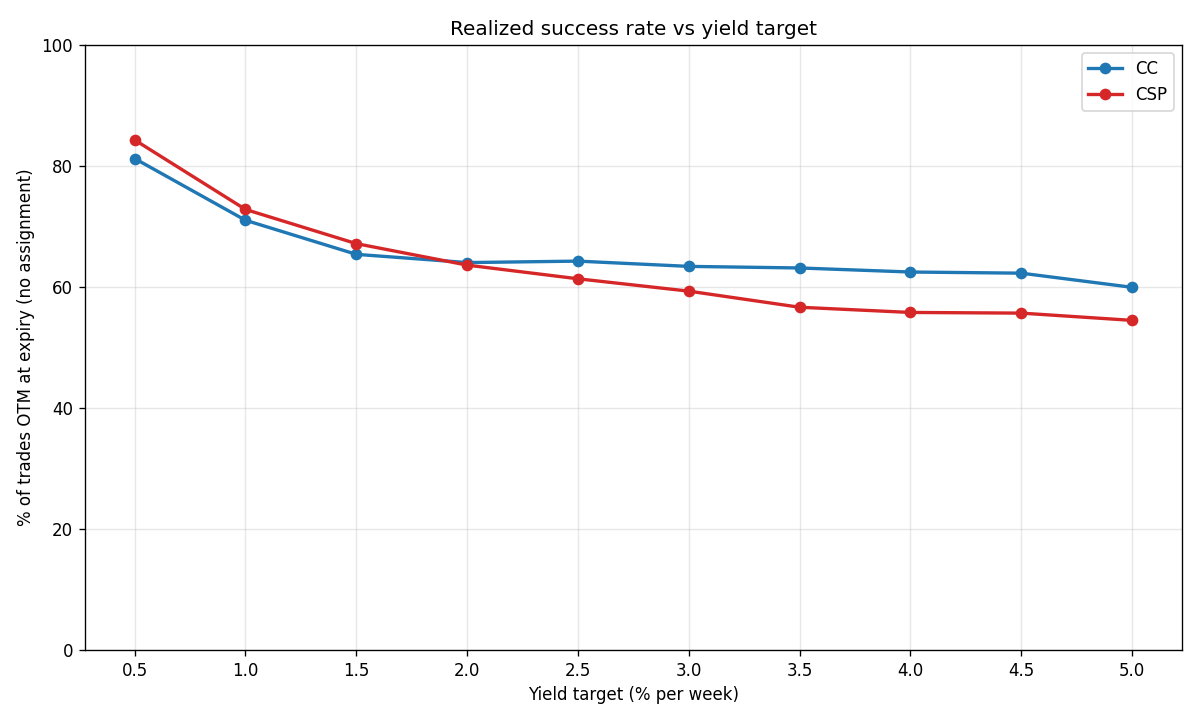

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for type_key, color in [("CC", "tab:blue"), ("CSP", "tab:red")]:
    sub = base_rate[base_rate["type"] == type_key]
    ax.plot(
        sub["yield_target"] * 100,
        sub["pct_OTM_at_exp"],
        marker="o",
        color=color,
        label=type_key,
        linewidth=2,
    )
ax.set_xlabel("Yield target (% per week)")
ax.set_ylabel("% of trades OTM at expiry (no assignment)")
ax.set_title("Realized success rate vs yield target")
ax.grid(alpha=0.3)
ax.legend()
ax.set_xticks([y * 100 for y in YIELD_TARGETS])
ax.set_ylim(0, 100)
plt.show()

### Plot: mean PnL vs yield target

Bid-fill basis (conservative): capital-adjusted weekly return.


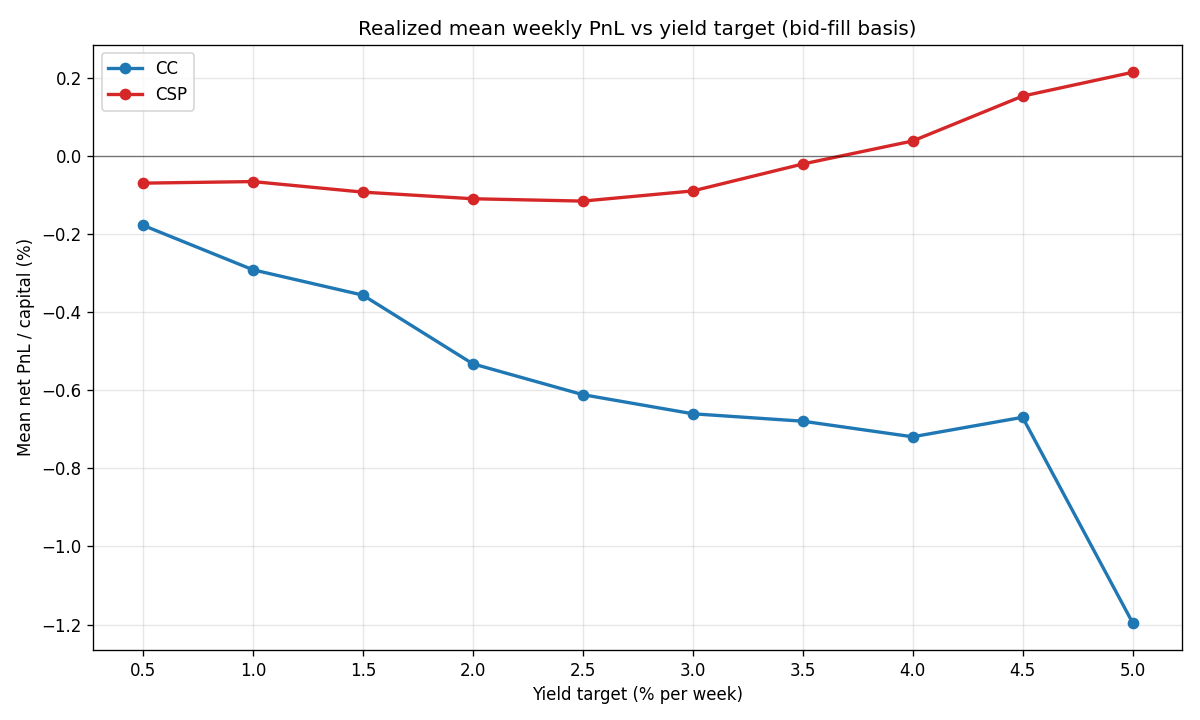

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for type_key, color in [("CC", "tab:blue"), ("CSP", "tab:red")]:
    sub = base_rate[base_rate["type"] == type_key]
    ax.plot(
        sub["yield_target"] * 100,
        sub["mean_pnl_pct_capital"],
        marker="o",
        color=color,
        label=type_key,
        linewidth=2,
    )
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Yield target (% per week)")
ax.set_ylabel("Mean net PnL / capital (%)")
ax.set_title("Realized mean weekly PnL vs yield target (bid-fill)")
ax.grid(alpha=0.3)
ax.legend()
ax.set_xticks([y * 100 for y in YIELD_TARGETS])
plt.show()

## Rows per ticker

Coverage varies — newer IPOs have fewer Mondays, lower-liquidity names hit the yield-out-of-reach filter more often.


In [9]:
ticker_counts = (
    labels.groupby("ticker")
    .size()
    .reset_index(name="n_rows")
    .sort_values("n_rows", ascending=False)
)
ticker_counts

,ticker,n_rows
10,GME,3656
32,TSLA,3524
8,COIN,3453
2,AMD,2887
25,RBLX,2790
18,NVDA,2754
14,LRCX,2503
20,PLTR,2336
1,AMAT,2271
23,QS,2209
